In [17]:
import pathlib
import pandas as pd
import pickle as pkl
import numpy as np
from icecream import ic
import sys
import os

In [18]:
from compute_full_df import get_acc

sys.path.append(os.path.abspath("../"))
from utils import get_rank_corrs, plot_rank_corrs, aggregate_rank_corrs

In [19]:
sys.path.append(os.path.abspath("../../"))
from paths import resources_path

scores_path = resources_path / pathlib.Path("scores/pca_deletion/scores.pkl")
# full_df_path = resources_path / pathlib.Path("full_dfs/pca_deletion/full_df.csv")
# full_df_path = resources_path / pathlib.Path("full_dfs/pca_deletion/full_df.csv")
full_df_path = resources_path / pathlib.Path("results/pca_deletion/pca_deletion_fast_run/full_df_self_computed.csv")
# full_df_path = resources_path / pathlib.Path("full_dfs/pca_deletion/full_df_self_computed.csv")

# Load `full_df`

In [20]:
full_df = pd.read_csv(full_df_path)

# Dataset subsetting

In [21]:
# get seeds from full_df
REF_SEEDS = list(full_df.seed1.unique())

# Seed filtering options for correlations:
#   "best"      -> best seed by probe task accuracy at ref_depth (current default)
#   "same"      -> only seed1 == seed2
#   "different" -> only seed1 != seed2
#   "all"       -> no seed filtering
#   "fixed"     -> only pairs where seed1 or seed2 matches FIXED_SEED
SEED_MODE = "best"
FIXED_SEED = None


def pca_sub_df(df, task, ref_depth, seed_mode=None, fixed_seed=None):
    if seed_mode is None:
        seed_mode = SEED_MODE
    if fixed_seed is None:
        fixed_seed = FIXED_SEED

    base_df = df[(df.layer1 == ref_depth) & (df.layer2 == ref_depth)]

    if seed_mode == "best":
        # find best seed for the task: reference seed
        data_dict = pkl.load(open(scores_path, "rb"))  # TODO: this seems weird - scores_path leads to a csv file
        accs = [get_acc(data_dict, probe_task, seed, layer=ref_depth, dims=0, run="average") for seed in REF_SEEDS]
        acc_dict = dict(zip(REF_SEEDS, accs))
        best_seed = max(acc_dict, key=acc_dict.get)
        return base_df[(base_df.seed1 == best_seed) | (base_df.seed2 == best_seed)]

    if seed_mode == "fixed":
        if fixed_seed is None:
            raise ValueError("seed_mode='fixed' requires FIXED_SEED to be set")
        return base_df[(base_df.seed1 == fixed_seed) | (base_df.seed2 == fixed_seed)]

    if seed_mode == "same":
        return base_df[base_df.seed1 == base_df.seed2]

    if seed_mode == "different":
        return base_df[base_df.seed1 != base_df.seed2]

    if seed_mode == "all":
        return base_df

    raise ValueError(f"Unknown seed_mode: {seed_mode}")


# Rank correlation results

In [22]:
probe_task = "SST-2"
# METRICS = ["softmax_rwka", "softmax_rwka_auc", "CKA", "mutual_knn", "mutual_knn_auc", "cka_rbf", "cka_rbf_auc"]
# METRICS = ["softmax_rwka", "softmax_rwka_auc", "PWCCA", "mean_cca_corr", "mean_sq_cca_corr", "CKA", "Procrustes", "cka_rbf", "cka_rbf_auc", "mutual_knn", "mutual_knn_auc", "cknna", "cknna_auc"]
METRICS = ["softmax_rwka", "softmax_rwka_auc", "PWCCA", "CKA", "Procrustes", "cka_rbf", "cka_rbf_auc", "mutual_knn", "mutual_knn_auc", "cknna", "cknna_auc"]
num_layers = 12
LAYERS = list(full_df.layer1.unique())

In [23]:
SEED_MODE = "different"
rho, rho_p, tau, tau_p, bad_fracs = aggregate_rank_corrs(full_df, 
                                                            probe_task, 
                                                            num_layers, 
                                                            METRICS, 
                                                            pca_sub_df, 
                                                            list_layers = LAYERS)

In [24]:
# average all of these over the different reference layers
for metric in METRICS:
    avg_rho = round(np.mean(rho[metric]), 3)
    avg_rho_p = format(np.mean(rho_p[metric]), ".1e")
    avg_tau = round(np.mean(tau[metric]), 3)
    avg_tau_p = format(np.mean(tau_p[metric]), ".1e")
    avg_bad_frac = round(np.mean(bad_fracs[metric]), 3)

    ic(metric, avg_rho, avg_rho_p, avg_tau, avg_tau_p, avg_bad_frac)

ic| metric: 'softmax_rwka'
    avg_rho: -0.315
    avg_rho_p: '9.9e-01'
    avg_tau: -0.226
    avg_tau_p: '1.0e+00'
    avg_bad_frac: 0.089
ic| metric: 'softmax_rwka_auc'
    avg_rho: 0.903
    avg_rho_p: '2.0e-24'
    avg_tau: 0.743
    avg_tau_p: '4.7e-19'
    avg_bad_frac: 0.0
ic| metric: 'PWCCA'
    avg_rho: 0.897
    avg_rho_p: '3.4e-24'
    avg_tau: 0.735
    avg_tau_p: '6.3e-19'
    avg_bad_frac: 0.0
ic| metric: 'CKA'
    avg_rho: 0.814
    avg_rho_p: '1.6e-15'
    avg_tau: 0.629
    avg_tau_p: '3.0e-13'
    avg_bad_frac: 0.0
ic| metric: 'Procrustes'
    avg_rho: 0.9
    avg_rho_p: '5.7e-24'
    avg_tau: 0.734
    avg_tau_p: '1.8e-18'
    avg_bad_frac: 0.0
ic| metric: 'cka_rbf'
    avg_rho: 0.902
    avg_rho_p: '4.2e-26'
    avg_tau: 0.739
    avg_tau_p: '7.6e-20'
    avg_bad_frac: 0.0
ic| metric: 'cka_rbf_auc'
    avg_rho: 0.891
    avg_rho_p: '1.2e-24'
    avg_tau: 0.718
    avg_tau_p: '1.1e-18'
    avg_bad_frac: 0.0
ic| metric: 'mutual_knn'
    avg_rho: 0.166
    avg_rho_p: 

ic| metric: 'Procrustes'
    avg_rho: 0.848
    avg_rho_p: '6.4e-35'
    avg_tau: 0.662
    avg_tau_p: '2.2e-28'
    avg_bad_frac: 0.001
ic| metric: 'CKA'
    avg_rho: 0.779
    avg_rho_p: '3.0e-28'
    avg_tau: 0.609
    avg_tau_p: '3.7e-24'
    avg_bad_frac: 0.004
ic| metric: 'PWCCA'
    avg_rho: 0.867
    avg_rho_p: '5.1e-38'
    avg_tau: 0.683
    avg_tau_p: '7.1e-31'
    avg_bad_frac: 0.001

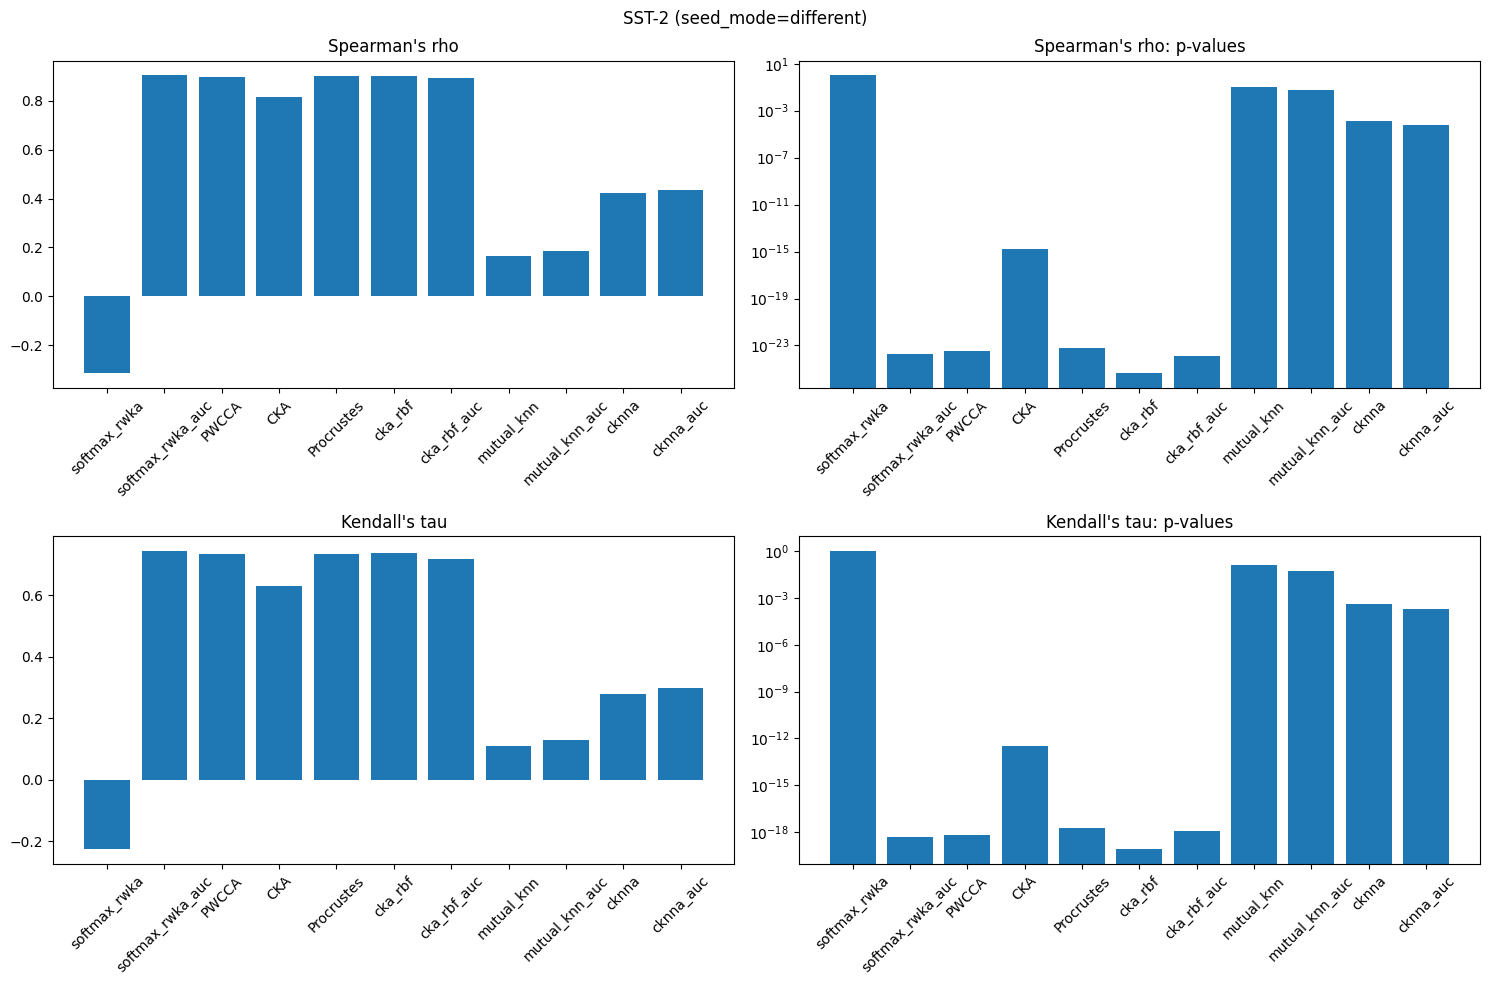

In [25]:
plot_rank_corrs(rho, rho_p, tau, tau_p, METRICS, title = f"{probe_task} (seed_mode={SEED_MODE})")

### Correlation with dims_kept (Spearman + Kendall tau)

Correlation with dims_kept (averaged across reference layers):
          metric  avg_spearman_rho avg_spearman_p  avg_kendall_tau avg_kendall_p
           PWCCA             0.998        1.5e-96            0.969       3.2e-37
         cka_rbf             0.996        2.1e-80            0.962       1.8e-36
      Procrustes             0.993        2.1e-77            0.953       6.0e-36
softmax_rwka_auc             0.981        6.5e-55            0.922       7.3e-33
     cka_rbf_auc             0.972        4.7e-52            0.898       7.6e-32
             CKA             0.899        4.3e-28            0.793       4.7e-24
           cknna             0.440        8.3e-05            0.312       1.0e-04
       cknna_auc             0.414        9.4e-05            0.266       5.4e-04
      mutual_knn             0.157        1.6e-01            0.110       1.8e-01
  mutual_knn_auc             0.151        9.5e-02            0.111       8.3e-02
    softmax_rwka            -0.373        1.0e

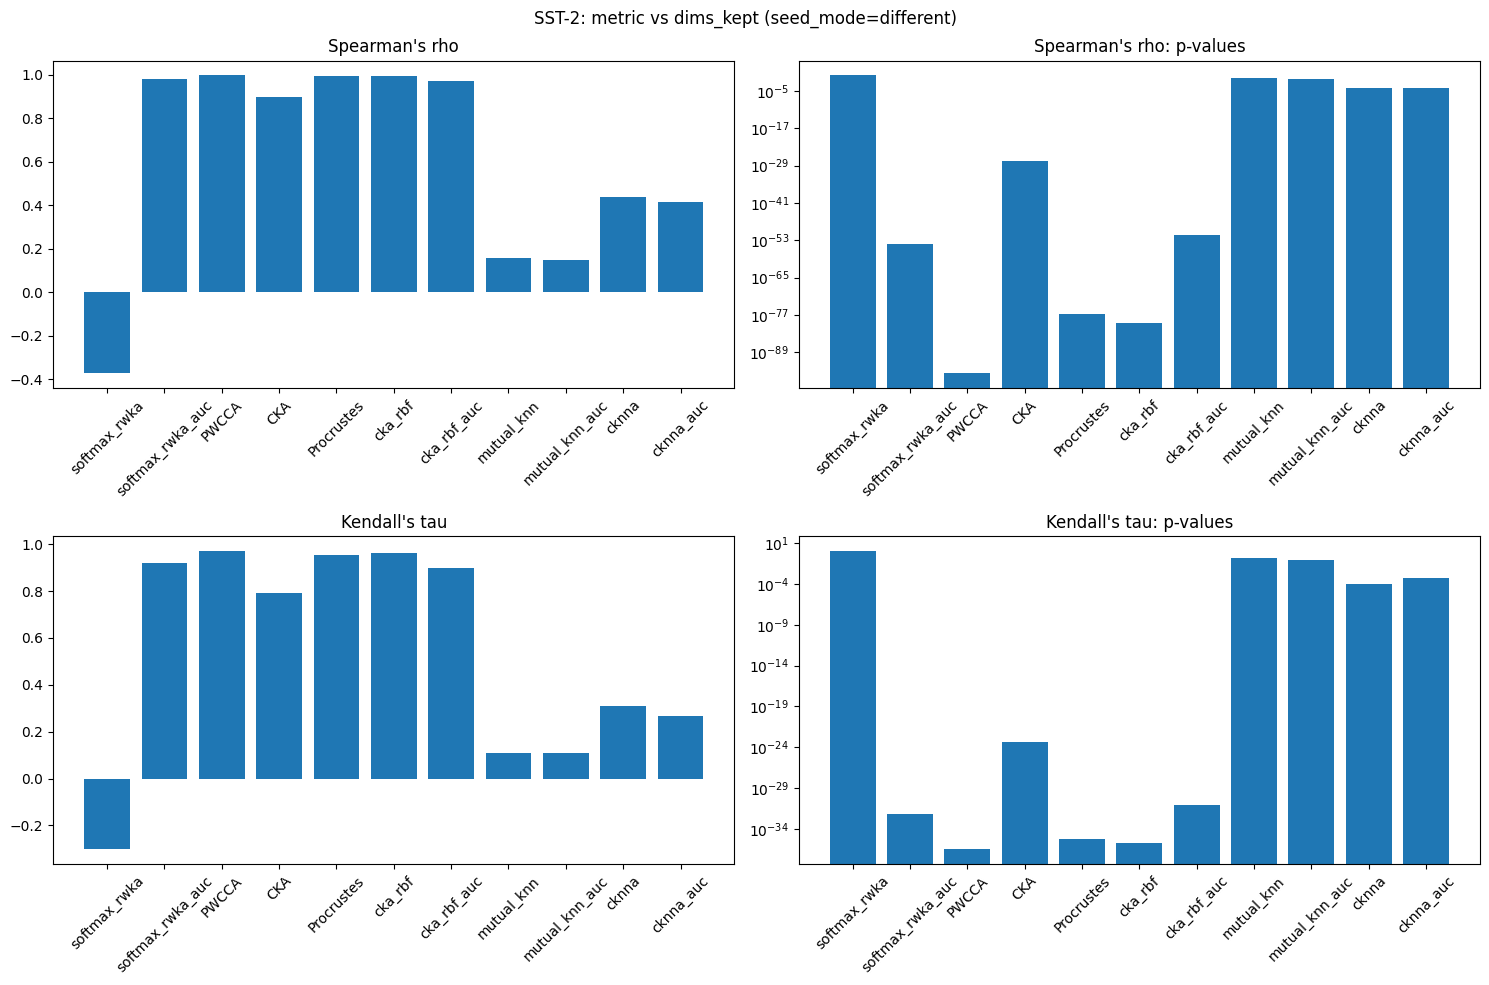

In [26]:
from scipy.stats import spearmanr, kendalltau

dims_col = "dims_deleted"
# if dims_col not in full_df.columns:
    # if "dims_deleted" in full_df.columns:
    #     total_dim = 768
    #     full_df = full_df.copy()
    #     full_df[dims_col] = total_dim - full_df["dims_deleted"].astype(float)
    # else:
    #     raise ValueError(
    #         f"No {dims_col} or dims_deleted column in full_df. Columns: {list(full_df.columns)}"
    #     )

dim_rho = {metric: [] for metric in METRICS}
dim_rho_p = {metric: [] for metric in METRICS}
dim_tau = {metric: [] for metric in METRICS}
dim_tau_p = {metric: [] for metric in METRICS}

for ref_depth in LAYERS:
    sub_df = pca_sub_df(full_df, probe_task, ref_depth)
    # if dims_col not in sub_df.columns:
    #     if "dims_deleted" in sub_df.columns:
    #         sub_df = sub_df.copy()
    #         sub_df[dims_col] = total_dim - sub_df["dims_deleted"].astype(float)
    #     else:
    #         raise ValueError(
    #             f"No {dims_col} or dims_deleted column in sub_df. Columns: {list(sub_df.columns)}"
    #         )

    for metric in METRICS:
        if metric not in sub_df.columns:
            print(f"Metric {metric} not found in dataframe columns. Skipping.")
            continue
        x = sub_df[metric]
        y = sub_df[dims_col]

        rho = spearmanr(x, y)
        rho_corr = rho.correlation
        rho_p = (rho.pvalue / 2) if rho_corr > 0 else (1 - rho.pvalue / 2)

        tau = kendalltau(x, y)
        tau_corr = tau.correlation
        tau_p = (tau.pvalue / 2) if tau_corr > 0 else (1 - tau.pvalue / 2)

        dim_rho[metric].append(rho_corr)
        dim_rho_p[metric].append(rho_p)
        dim_tau[metric].append(tau_corr)
        dim_tau_p[metric].append(tau_p)

rows = []
for metric in METRICS:
    if len(dim_rho[metric]) == 0:
        continue
    rows.append(
        {
            "metric": metric,
            "avg_spearman_rho": round(float(np.mean(dim_rho[metric])), 3),
            "avg_spearman_p": format(float(np.mean(dim_rho_p[metric])), ".1e"),
            "avg_kendall_tau": round(float(np.mean(dim_tau[metric])), 3),
            "avg_kendall_p": format(float(np.mean(dim_tau_p[metric])), ".1e"),
        }
    )

dim_corr_df = pd.DataFrame(rows).sort_values("avg_spearman_rho", ascending=False)
print("Correlation with dims_kept (averaged across reference layers):")
print(dim_corr_df.to_string(index=False))

metrics_present = [m for m in METRICS if len(dim_rho[m]) > 0]
if metrics_present:
    plot_rank_corrs(
        dim_rho,
        dim_rho_p,
        dim_tau,
        dim_tau_p,
        metrics_present,
        title=f"{probe_task}: metric vs dims_kept (seed_mode={SEED_MODE})",
    )
else:
    print("No metrics with dims_kept correlations found.")
